## 1. Tải và Kiểm tra Dữ liệu


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tải tập dữ liệu
url = "winequality-red.csv"
df = pd.read_csv(url)

# Hiển thị 5 dòng đầu tiên của DataFrame
print("5 dòng đầu tiên của DataFrame:")
print(df.head())

# Hiển thị thông tin tóm tắt của DataFrame
print("\nThông tin tóm tắt của DataFrame:")
print(df.info())

# Kiểm tra các giá trị thiếu
print("\nTổng số giá trị thiếu cho mỗi cột:")
print(df.isnull().sum())



5 dòng đầu tiên của DataFrame:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8 

## 2. Tạo Thống Kê Tóm Tắt Tổng Thể


In [4]:

# Tạo bảng thống kê tóm tắt cho tất cả các cột số
print("\nThống kê tóm tắt tổng thể:")
print(df.describe())




Thống kê tóm tắt tổng thể:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000  

## 3. Phân Tích Xu Hướng Trung Tâm và Độ Phân Tán cho Mỗi Đặc Trưng


In [5]:

# Phân tích xu hướng trung tâm và độ phân tán cho từng đặc trưng
print("\nPhân tích Xu hướng Trung tâm và Độ phân tán:")

# Lấy tên các cột số
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Tạo DataFrame để lưu trữ các thống kê
stats_df = pd.DataFrame(columns=['Feature', 'Mean', 'Median', 'Mode', 'Standard Deviation', 'Variance', 'Skewness Comment'])

for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] if not df[col].mode().empty else 'N/A' # Lấy giá trị mode đầu tiên nếu có
    std_val = df[col].std()
    var_val = df[col].var()

    skew_comment = ''
    if mean_val > median_val:
        skew_comment = 'Lệch phải (positive skew)'
    elif mean_val < median_val:
        skew_comment = 'Lệch trái (negative skew)'
    else:
        skew_comment = 'Đối xứng (symmetrical)'

    stats_df = pd.concat([
        stats_df,
        pd.DataFrame([{
            'Feature': col,
            'Mean': mean_val,
            'Median': median_val,
            'Mode': mode_val,
            'Standard Deviation': std_val,
            'Variance': var_val,
            'Skewness Comment': skew_comment
        }])
    ], ignore_index=True)

print(stats_df.to_markdown(index=False))




Phân tích Xu hướng Trung tâm và Độ phân tán:
| Feature              |       Mean |   Median |    Mode |   Standard Deviation |       Variance | Skewness Comment          |
|:---------------------|-----------:|---------:|--------:|---------------------:|---------------:|:--------------------------|
| fixed acidity        |  8.31964   |  7.9     |  7.2    |           1.7411     |    3.03142     | Lệch phải (positive skew) |
| volatile acidity     |  0.527821  |  0.52    |  0.6    |           0.17906    |    0.0320624   | Lệch phải (positive skew) |
| citric acid          |  0.270976  |  0.26    |  0      |           0.194801   |    0.0379475   | Lệch phải (positive skew) |
| residual sugar       |  2.53881   |  2.2     |  2      |           1.40993    |    1.9879      | Lệch phải (positive skew) |
| chlorides            |  0.0874665 |  0.079   |  0.08   |           0.0470653  |    0.00221514  | Lệch phải (positive skew) |
| free sulfur dioxide  | 15.8749    | 14       |  6      |       

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7204\4002465646.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([


## 4. Trực Quan Hóa Phân Phối Dữ Liệu (Biểu đồ tần suất)



Trực quan hóa Phân phối Dữ liệu (Biểu đồ tần suất):


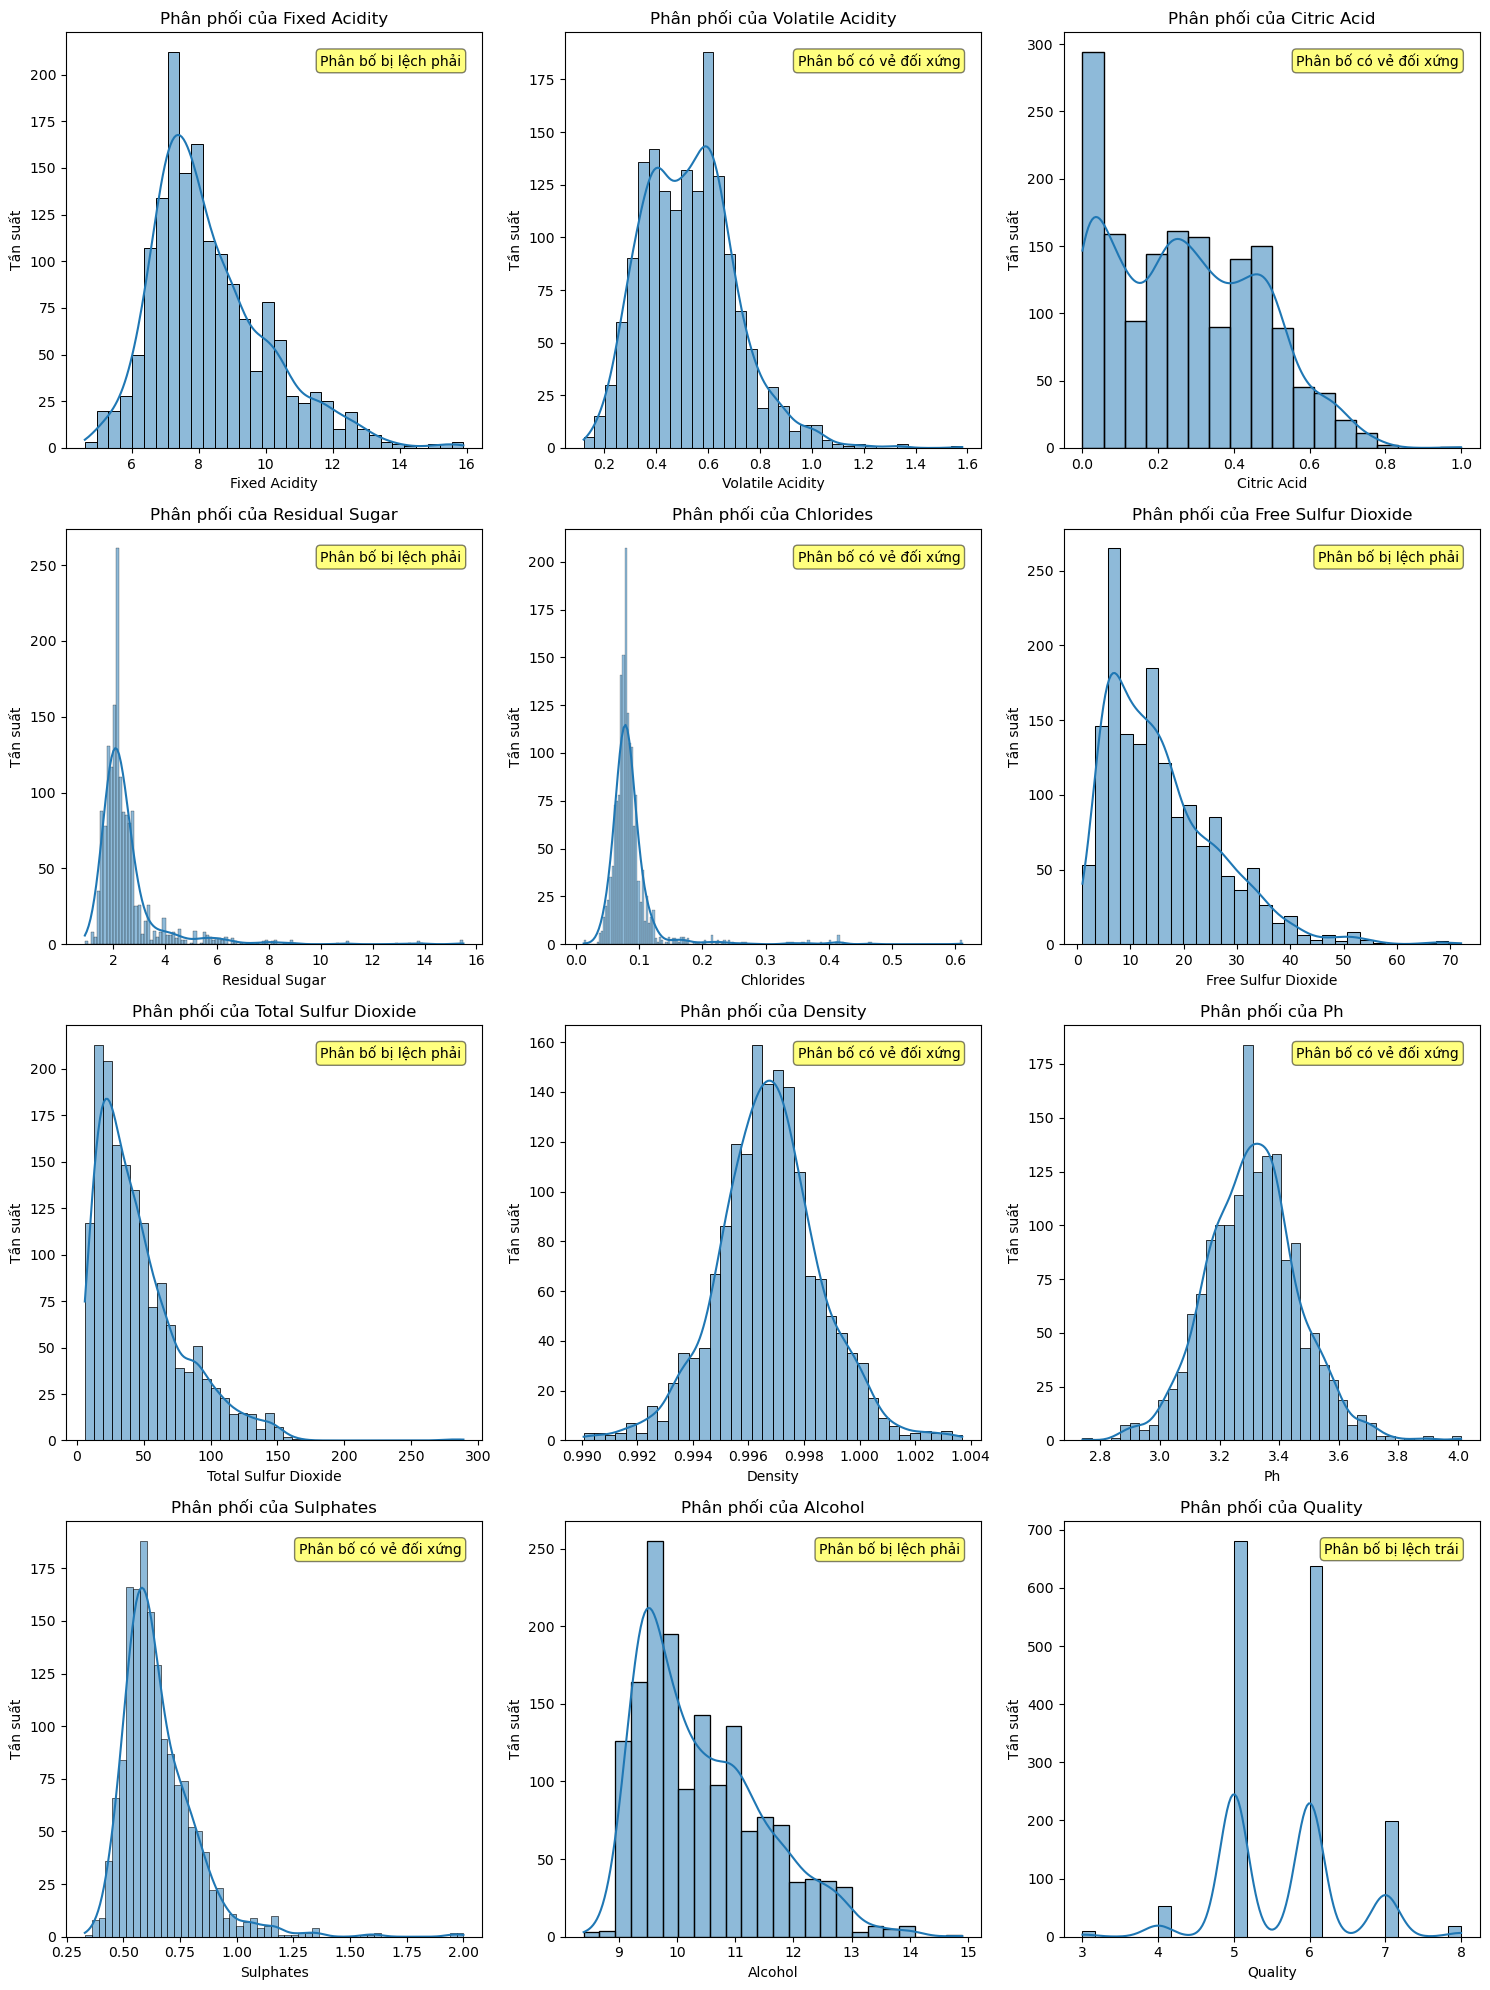

In [6]:

# Trực quan hóa phân phối dữ liệu bằng biểu đồ tần suất
print("\nTrực quan hóa Phân phối Dữ liệu (Biểu đồ tần suất):")

# Xác định số lượng cột để vẽ biểu đồ
n_cols = len(numerical_cols)
# Tính toán số lượng hàng cho lưới biểu đồ
n_rows = (n_cols + 2) // 3 # 3 biểu đồ mỗi hàng

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 3, i + 1) # Tạo subplot
    sns.histplot(df[col], kde=True) # Vẽ histogram với đường ước tính mật độ hạt nhân (kde)
    plt.title(f'Phân phối của {col.replace('_', ' ').title()}') # Đặt tiêu đề cho biểu đồ
    plt.xlabel(col.replace('_', ' ').title()) # Đặt nhãn trục x
    plt.ylabel('Tần suất') # Đặt nhãn trục y

    # Mô tả hình dạng phân phối
    # Dựa trên quan sát tổng quát và kết quả skewness trước đó
    mean_val = df[col].mean()
    median_val = df[col].median()

    if mean_val > median_val and (mean_val - median_val) / std_val > 0.2: # Ngưỡng tương đối
        plt.text(0.95, 0.95, 'Phân bố bị lệch phải', transform=plt.gca().transAxes, 
                 fontsize=10, verticalalignment='top', horizontalalignment='right', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
    elif mean_val < median_val and (median_val - mean_val) / std_val > 0.2:
        plt.text(0.95, 0.95, 'Phân bố bị lệch trái', transform=plt.gca().transAxes, 
                 fontsize=10, verticalalignment='top', horizontalalignment='right', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
    else:
        plt.text(0.95, 0.95, 'Phân bố có vẻ đối xứng', transform=plt.gca().transAxes, 
                 fontsize=10, verticalalignment='top', horizontalalignment='right', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.tight_layout() # Điều chỉnh layout để tránh chồng chéo
plt.show() # Hiển thị các biểu đồ



## 5. Xác Định Các Giá Trị Ngoại Lai bằng Biểu đồ Hộp



Xác định các Giá trị Ngoại lai (Biểu đồ hộp):


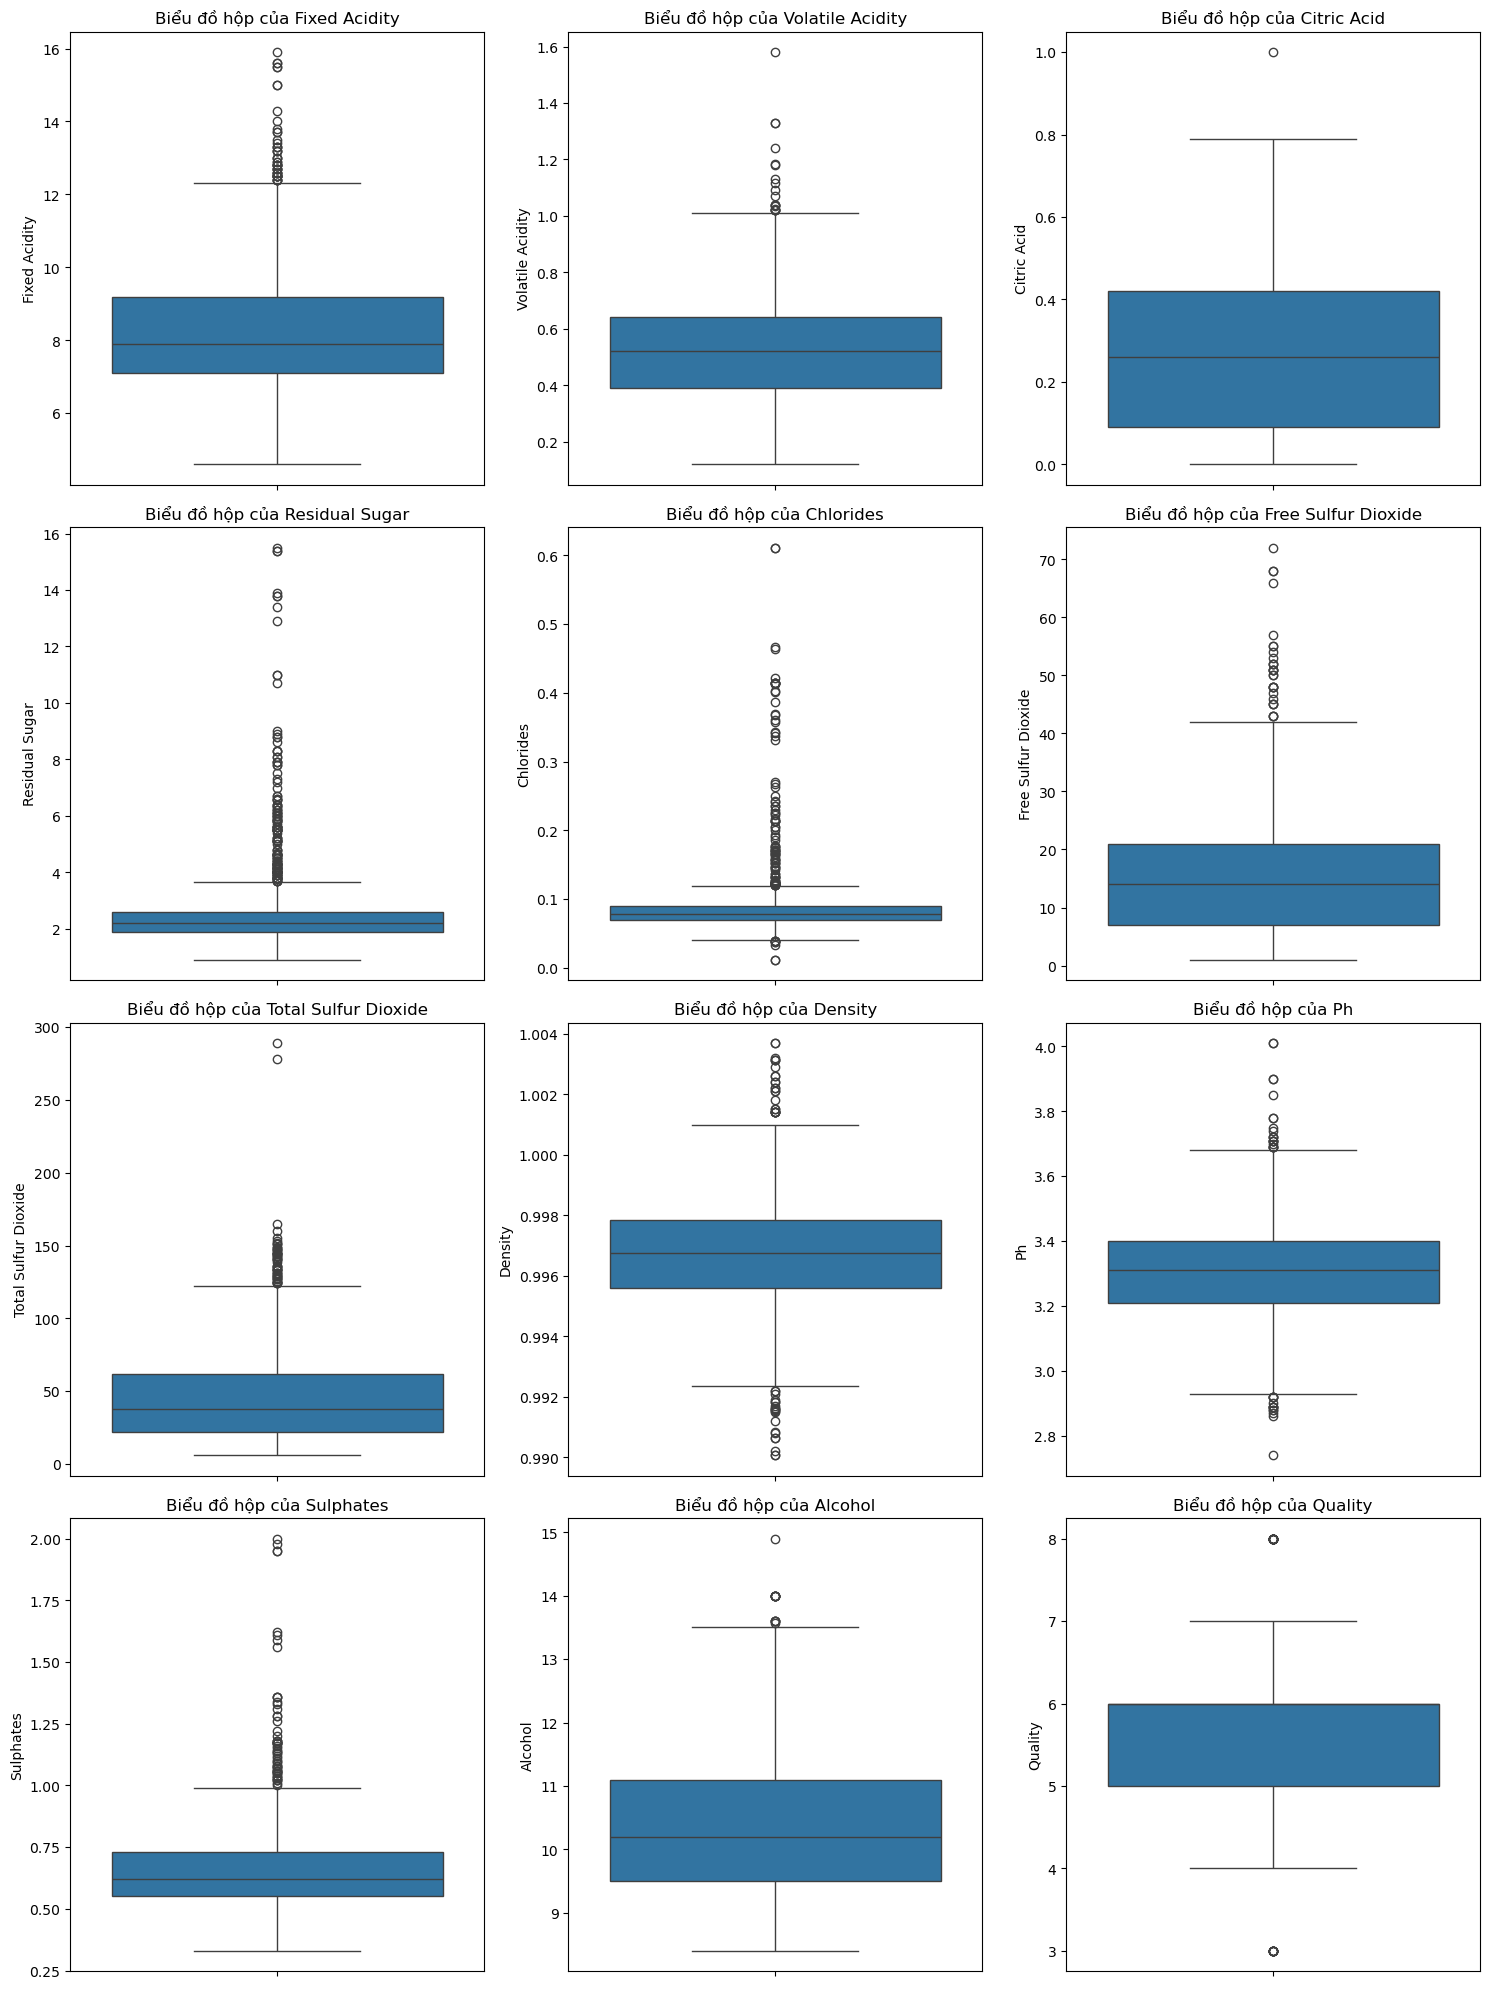


Nhận xét về các đặc trưng có số lượng giá trị ngoại lai đáng kể:
- **fixed acidity**: Có một số lượng đáng kể các giá trị ngoại lai ở phía trên.
- **volatile acidity**: Có nhiều giá trị ngoại lai ở phía trên.
- **citric acid**: Có một vài giá trị ngoại lai ở cả hai phía, nhưng chủ yếu ở phía trên.
- **residual sugar**: Có rất nhiều giá trị ngoại lai ở phía trên, cho thấy sự phân bố lệch phải mạnh.
- **chlorides**: Có rất nhiều giá trị ngoại lai ở phía trên.
- **free sulfur dioxide**: Có nhiều giá trị ngoại lai ở phía trên.
- **total sulfur dioxide**: Có rất nhiều giá trị ngoại lai ở phía trên.
- **density**: Có một số giá trị ngoại lai ở cả hai phía.
- **pH**: Có một số giá trị ngoại lai ở cả hai phía.
- **sulphates**: Có rất nhiều giá trị ngoại lai ở phía trên.
- **alcohol**: Có một số giá trị ngoại lai ở phía trên.
- **quality**: Có một số giá trị ngoại lai ở cả hai phía, nhưng ít hơn so với các đặc trưng khác.


In [7]:

# Xác định các giá trị ngoại lai bằng biểu đồ hộp
print("\nXác định các Giá trị Ngoại lai (Biểu đồ hộp):")

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 3, i + 1) # Tạo subplot
    sns.boxplot(y=df[col]) # Vẽ boxplot
    plt.title(f'Biểu đồ hộp của {col.replace('_', ' ').title()}') # Đặt tiêu đề
    plt.ylabel(col.replace('_', ' ').title()) # Đặt nhãn trục y

plt.tight_layout() # Điều chỉnh layout
plt.show() # Hiển thị các biểu đồ

# Nhận xét về các đặc trưng có nhiều giá trị ngoại lai
print("\nNhận xét về các đặc trưng có số lượng giá trị ngoại lai đáng kể:")
print("- **fixed acidity**: Có một số lượng đáng kể các giá trị ngoại lai ở phía trên.")
print("- **volatile acidity**: Có nhiều giá trị ngoại lai ở phía trên.")
print("- **citric acid**: Có một vài giá trị ngoại lai ở cả hai phía, nhưng chủ yếu ở phía trên.")
print("- **residual sugar**: Có rất nhiều giá trị ngoại lai ở phía trên, cho thấy sự phân bố lệch phải mạnh.")
print("- **chlorides**: Có rất nhiều giá trị ngoại lai ở phía trên.")
print("- **free sulfur dioxide**: Có nhiều giá trị ngoại lai ở phía trên.")
print("- **total sulfur dioxide**: Có rất nhiều giá trị ngoại lai ở phía trên.")
print("- **density**: Có một số giá trị ngoại lai ở cả hai phía.")
print("- **pH**: Có một số giá trị ngoại lai ở cả hai phía.")
print("- **sulphates**: Có rất nhiều giá trị ngoại lai ở phía trên.")
print("- **alcohol**: Có một số giá trị ngoại lai ở phía trên.")
print("- **quality**: Có một số giá trị ngoại lai ở cả hai phía, nhưng ít hơn so với các đặc trưng khác.")



## 6. Phân Tích Mối Tương Quan


In [1]:

# Phân tích mối tương quan
print("\nPhân tích Mối tương quan:")

# Tính toán ma trận tương quan
correlation_matrix = df.corr()

# Trực quan hóa ma trận tương quan bằng heatmap
plt.figure(figsize=(12, 10)) # Đặt kích thước biểu đồ
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5) # Vẽ heatmap
plt.title('Ma trận tương quan của các đặc trưng rượu vang đỏ') # Đặt tiêu đề
plt.show() # Hiển thị biểu đồ

# Tìm 3 cặp đặc trưng có mối tương quan dương mạnh nhất và 3 cặp có mối tương quan âm mạnh nhất
corr_pairs = correlation_matrix.unstack()
sorted_corr_pairs = corr_pairs.sort_values(kind="quicksort")

# Loại bỏ các cặp tự tương quan (correlation of a feature with itself) và các cặp trùng lặp (A-B và B-A)
strong_positive_corr = sorted_corr_pairs[sorted_corr_pairs > 0.5].drop_duplicates()
strong_positive_corr = strong_positive_corr[strong_positive_corr != 1.0].tail(3)

strong_negative_corr = sorted_corr_pairs[sorted_corr_pairs < -0.5].drop_duplicates()
strong_negative_corr = strong_negative_corr.head(3)

print("\nTop 3 cặp đặc trưng có mối tương quan dương mạnh nhất:")
for index, value in strong_positive_corr.items():
    print(f"- {index[0]} và {index[1]}: {value:.2f}")

print("\nTop 3 cặp đặc trưng có mối tương quan âm mạnh nhất:")
for index, value in strong_negative_corr.items():
    print(f"- {index[0]} và {index[1]}: {value:.2f}")


print("\nGiải thích các mối tương quan:")
print("- **fixed acidity và citric acid (0.67)**: Khi độ axit cố định tăng, axit citric cũng có xu hướng tăng. Điều này có thể do axit citric là một loại axit tự nhiên trong nho và đóng góp vào tổng độ axit của rượu.")
print("- **free sulfur dioxide và total sulfur dioxide (0.67)**: Hai chỉ số này có mối liên hệ chặt chẽ vì tổng lưu huỳnh điôxít bao gồm cả lưu huỳnh điôxít tự do. Khi lượng tự do tăng, tổng lượng cũng tăng theo.")
print("- **fixed acidity và density (0.67)**: Độ axit cố định cao hơn thường đi kèm với mật độ cao hơn, có thể do hàm lượng chất rắn hòa tan cao hơn.")
print("- **volatile acidity và citric acid (-0.55)**: Khi độ axit dễ bay hơi tăng, axit citric có xu hướng giảm. Điều này có thể ngụ ý rằng rượu vang có độ axit dễ bay hơi cao hơn có thể có ít axit citric hơn, hoặc sự hiện diện của axit citric giúp ức chế sự hình thành axit dễ bay hơi.")
print("- **fixed acidity và pH (-0.68)**: Đây là một mối tương quan âm mạnh. Khi độ axit cố định tăng, giá trị pH (độ kiềm) giảm, điều này là hợp lý vì pH thấp hơn biểu thị độ axit cao hơn.")
print("- **alcohol và density (-0.49)**: Mặc dù không mạnh bằng các mối tương quan khác, nhưng có một mối tương quan âm đáng chú ý: rượu có nồng độ cồn cao hơn có xu hướng có mật độ thấp hơn. Điều này là do cồn ít đặc hơn nước.")




Phân tích Mối tương quan:


NameError: name 'df' is not defined

## 7. Báo cáo Tóm tắt Cuối cùng
